In [16]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [17]:
X_train = np.load("../data/X_train.npy")
X_test = np.load("../data/X_test.npy")

y_train = np.load("../data/y_train.npy")
y_test = np.load("../data/y_test.npy")

In [18]:
print(X_train.shape)
print(X_test.shape)

(56000, 4)
(14000, 4)


In [19]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [20]:
class ClassicalNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(4,16),

            nn.ReLU(),

            nn.Linear(16,10)

        )

    def forward(self,x):

        return self.network(x)

In [21]:
model = ClassicalNN()

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [22]:
epochs = 50

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X_train)

    loss = criterion(outputs, y_train)

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 5 == 0:

        print(
            epoch,
            loss.item()
        )

0 2.558823823928833
5 2.5142550468444824
10 2.471590518951416
15 2.4308054447174072
20 2.391801357269287
25 2.3544108867645264
30 2.3184289932250977
35 2.283627986907959
40 2.2497851848602295
45 2.216712236404419


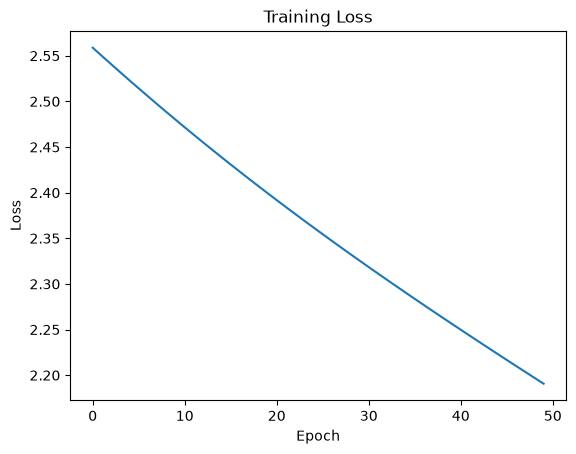

In [23]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [24]:
with torch.no_grad():

    predictions = model(X_test)

predicted = predictions.argmax(dim=1)

accuracy = accuracy_score(
    y_test,
    predicted
)

print(accuracy)

0.12042857142857143


In [25]:
print(

classification_report(

    y_test,

    predicted

)

)

              precision    recall  f1-score   support

           0       0.01      0.00      0.00      1381
           1       0.12      0.00      0.00      1575
           2       0.80      0.21      0.34      1398
           3       0.03      0.06      0.04      1428
           4       0.00      0.00      0.00      1365
           5       0.04      0.03      0.03      1263
           6       0.20      0.23      0.22      1375
           7       0.05      0.18      0.08      1459
           8       0.06      0.02      0.03      1365
           9       0.21      0.47      0.29      1391

    accuracy                           0.12     14000
   macro avg       0.15      0.12      0.10     14000
weighted avg       0.15      0.12      0.10     14000



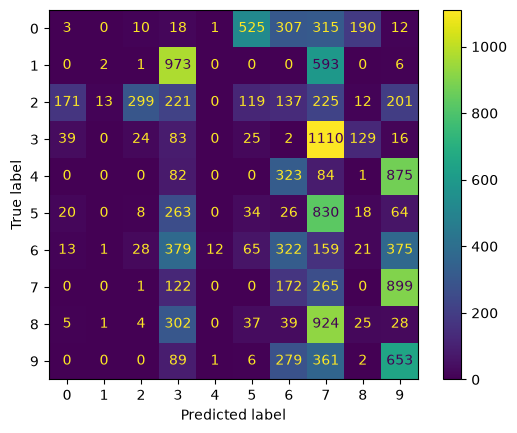

In [26]:
cm = confusion_matrix(
    y_test,
    predicted
)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [27]:
np.save(
    "../results/classical/predictions.npy",
    predicted.numpy()
)